# 1. Hazırlık ve Kütüphaneler

Notebook'un ilk hücresinde gerekli kütüphaneleri içe aktaralım.

In [1]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
import os

# Dosya yollarını mimariye uygun tanımlayalım
DATA_PATH = os.path.join('..', 'data')
IP_DATA_FILE = os.path.join(DATA_PATH, 'Indian_pines_corrected.mat')
IP_GT_FILE = os.path.join(DATA_PATH, 'Indian_pines_gt.mat')

# 2. Verinin Yüklenmesi ve Yapı Denetimi

Indian Pines (IP) veri seti, AVIRIS sensörü ile toplanmış olup 145x145 piksel boyutundadır. Başlangıçta 220 bant olan veri, su emilim bölgeleri çıkarılarak 200 banta indirilmiştir.

In [2]:
# Veriyi yükle
data = sio.loadmat(IP_DATA_FILE)['indian_pines_corrected']
gt = sio.loadmat(IP_GT_FILE)['indian_pines_gt']

# Boyut kontrolü
print(f"Görüntü Boyutu: {data.shape}") # (145, 145, 200) bekleniyor
print(f"Etiket (GT) Boyutu: {gt.shape}") # (145, 145) bekleniyor

Görüntü Boyutu: (145, 145, 200)
Etiket (GT) Boyutu: (145, 145)


# 3. Sınıf İsimlerinin Tanımlanması

Veri setinde 16 farklı geçerli sınıf bulunmaktadır. Ancak etiketlerde "0" değeri Undefined (Tanımsız) pikselleri temsil eder. Analiz sırasında bu 0 etiketli pikseller filtrelenmelidir.

In [3]:
class_names = {
    0: "Undefined", 1: "Alfalfa", 2: "Corn-notill", 3: "Corn-mintill",
    4: "Corn", 5: "Grass-pasture", 6: "Grass-trees", 7: "Grass-pasture-mowed",
    8: "Hay-windrowed", 9: "Oats", 10: "Soybean-notill", 11: "Soybean-mintill",
    12: "Soybean-clean", 13: "Wheat", 14: "Woods",
    15: "Buildings-grass-trees-drives", 16: "Stone-steel-towers"
}

# Sınıf sayısını yazdır
print(f"Toplam Sınıf Sayısı (0 dahil): {len(class_names)}")

Toplam Sınıf Sayısı (0 dahil): 17


# 4. Veriyi Görselleştirme

Yüklediğimiz verinin doğru olduğunu anlamak için rastgele bir bandı ve yer gerçeği (ground truth) haritasını çizdirelim.

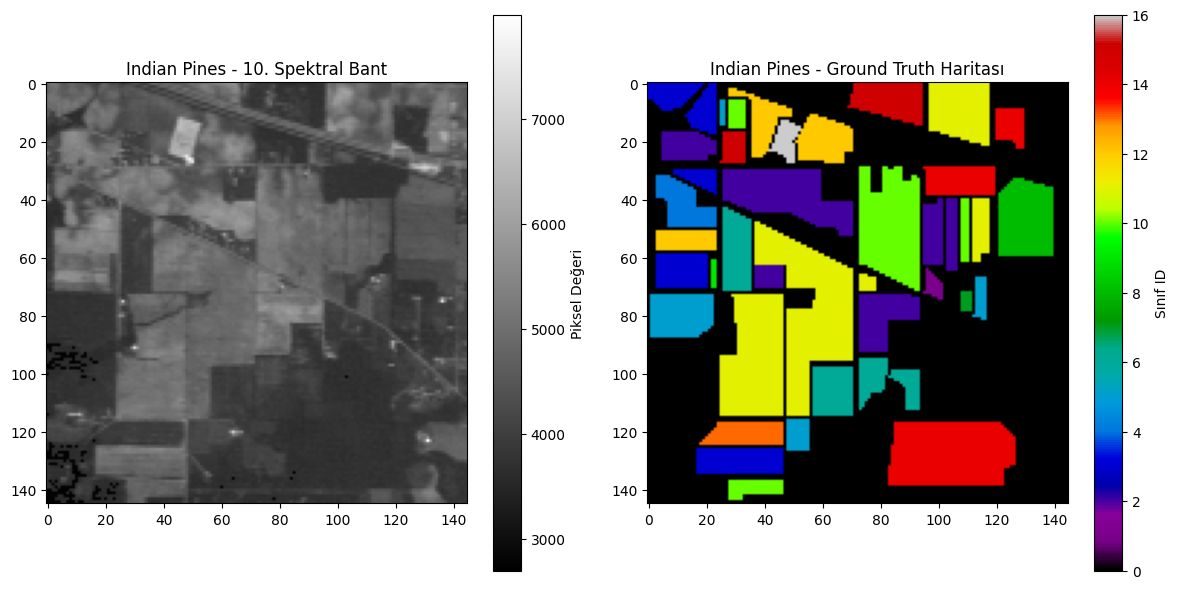

In [4]:
plt.figure(figsize=(12, 6))

# Rastgele bir spektral bant (Örn: 10. bant)
plt.subplot(1, 2, 1)
plt.imshow(data[:, :, 10], cmap='gray')
plt.title('Indian Pines - 10. Spektral Bant')
plt.colorbar(label='Piksel Değeri')

# Yer Gerçeği (Ground Truth)
plt.subplot(1, 2, 2)
plt.imshow(gt, cmap='nipy_spectral')
plt.colorbar(label='Sınıf ID')
plt.title('Indian Pines - Ground Truth Haritası')

plt.tight_layout()
plt.show()